In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-01-14 12:24:31.620199: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-14 12:24:31.638420: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-14 12:24:31.638441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-14 12:24:31.638974: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-14 12:24:31.642810: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model

In [3]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000
model = mlp(256,traces_dim)
n_prof= 200000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "ID"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


2025-01-14 12:24:32.829347: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-14 12:24:32.844443: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-14 12:24:32.844484: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-14 12:24:32.846391: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-14 12:24:32.846431: I external/local_xla/xla/stream_executor

Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000)]            0         
                                                                 
 dense (Dense)               (None, 100)               200100    
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 100)               10100     
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 100)               

In [4]:
layers = ["conv_1", "conv_2","fc_1", "fc_2"]

input_layers = ["bn_1", "bn_2", "fc_2", "output"]

In [40]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()

def reload_model_att(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
    weights = model.get_weights()
    print(len(weights))
    squared_sum = [np.linalg.norm(wl) for wl in weights]
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    #tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = model.predict(dataset.x_attack).copy()
    return information(tmp_att, dataset.attack_labels, 256), squared_sum

# if layers[layer].__contains__("conv"):
#     og_1, og_2 = tmp.shape[1], tmp.shape[2]
#     tmp = tmp.reshape(tmp.shape[0], og_1*og_2)
#     #print(tmp.shape)
#     s1_att = s1_att.reshape(s1_att.shape[0], og_1*og_2)
#reload_model()


In [6]:
tmp[layer].shape
snr = snr_fast(tmp[layer], dataset.share5_profiling[target_byte])
#np.min(tmp)
snr


array([0.13441931, 0.00988477, 0.03912871, 0.02413129, 0.0664468 ,
       0.01023357, 0.06065469, 0.14938428, 0.00439472, 0.25471141,
       0.03668561, 0.31750983, 0.01452047, 0.15323056, 0.0169967 ,
       0.06821661, 0.16213313, 0.44746998, 0.02017842, 0.01019916,
       0.0032868 , 0.16605568, 0.23343442, 0.04808956, 0.02505723,
       0.17591439, 0.01795659, 0.01029895, 0.00575739, 0.19261374,
       0.05702207, 0.01381239, 0.20063915, 0.10572817, 0.00543566,
       0.32038401, 0.23189189, 0.02920006, 0.03212244, 0.04241056,
       0.01071412, 0.61333615, 0.30138218, 0.06550538, 0.57161176,
       0.00652   , 0.17554032, 0.01711684, 0.00876844, 0.02967457,
       0.41496288, 0.01510072, 0.02803875, 0.08647725, 0.01328166,
       0.00246258, 0.01686561, 0.05508142, 0.08906255, 0.00831088,
       0.42494687, 0.24205495, 0.0101544 , 0.18529815, 0.0052566 ,
       0.29269771, 0.00511499, 0.36811689, 0.02460293, 0.00730159,
       0.03214312, 0.07177371, 0.31557467, 0.07079716, 0.05405

In [7]:
#Detetrmine appropriate number of componenets:
reload_model(99)
new_model_out= Model(model.layers[layer+1].input, model.layers[-1].output)

# orig_preds = new_model_out.predict(tmp_att[layer])
# from profiling_and_attack import information
# print(information(orig_preds, dataset.attack_labels, 256))
# for comps in [2, 4, 8, 16, 32, 40]:
#     pca = PCA(n_components=comps)
#     pca.fit(tmp[layer])
#     s1_prof = pca.transform(tmp_att[layer])
#     ablated_preds = new_model_out.predict(pca.inverse_transform(s1_prof))

#     print(comps, information(ablated_preds, dataset.attack_labels, 256))




313/313 [==============================] - 0s 1ms/step


In [8]:

# new_model_out= Model(model.layers[layer+1].input, model.layers[-1].output)
# COMPS = 32
# #orig_preds = model.predict(dataset.x_profiling)
# pca = PCA(n_components=COMPS)
# pca.fit(tmp[layer])
# s1_prof = pca.transform(tmp_att[layer])

# orig_preds = new_model_out.predict(pca.inverse_transform(s1_prof))
# patched_activs = s1_prof.copy()

# from profiling_and_attack import information
# print(information(orig_preds, dataset.attack_labels, 256))
# ablated_list_pis = []
# for comp in range(s1_prof.shape[1]):
#     patched_activs = s1_prof.copy()
#     patched_activs[:, comp] = np.mean(s1_prof[:, comp])*0
#     ablated_preds = new_model_out.predict(pca.inverse_transform(patched_activs))
#     ablated_list_pis.append(information(ablated_preds, dataset.attack_labels, 256))
#     print(comp, ablated_list_pis[-1])

# patched_activs = s1_prof.copy()
# for comp in range(20, s1_prof.shape[1]):
    
#     patched_activs[:, comp] = np.mean(s1_prof[:, comp])

# ablated_preds = new_model_out.predict(pca.inverse_transform(patched_activs))
# print(information(ablated_preds, dataset.attack_labels, 256))

# #patched_activs[:, COMP] *= 0
# #patched_activs[weird_comp_off, 1] = 15
# #print(patched_activs)




In [9]:
bins=20
s1_att = pca.transform(tmp_att[layer])
for neuron in range(8):
    plt.hist(s1_att[:, neuron], bins, label=f"All")
    # for j in [0,1]:
    #     #indices = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8)) ==j)[0]
    #     indices = np.where(dataset.share5_profiling[target_byte, :] % 2 == j)[0] 
    #     plt.hist(s1_prof[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
    #     pass



    plt.legend()
    plt.show()

    mean, var = np.average(s1_att[:, neuron]), np.std(s1_att[:, neuron])
    avg0 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]  % 2 ==0)[0], neuron])
    avg128 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]% 2 ==1)[0], neuron])
    num_activs = len(np.where(s1_att[:, neuron] > 0)[0])/s1_att.shape[0]
    #avg255 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte] == 255)[0], neuron])
    print(f"Neuron {neuron}, {snr[neuron]}, {num_activs}:    0: {avg0}, 128: {avg128}")

NameError: name 'pca' is not defined

(200000, 16)
0 0.0001147678815761906
1 6.271580443650147e-05
2 0.00010371775772447504
3 7.702744171120352e-05
4 0.00015044092544095892
5 4.4956559017903095e-05
6 0.00028569319913306134
7 0.00046502645093685324


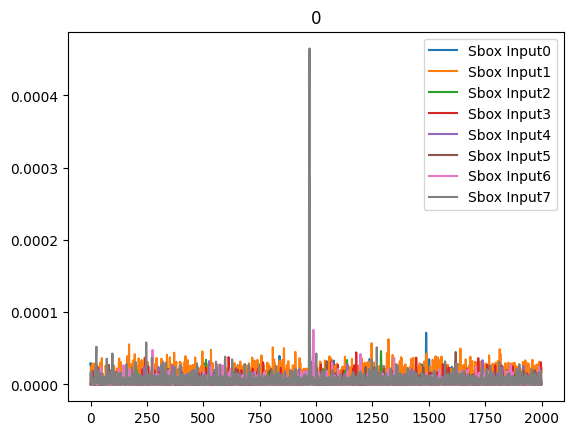

(200000, 16)
0 0.006954429594242818
1 0.03194323283408472
2 0.001286601673610306
3 0.0012460512092744907
4 0.0006946611952420069
5 0.0008101709021396886
6 0.0009342281771669881
7 0.001120241925794211


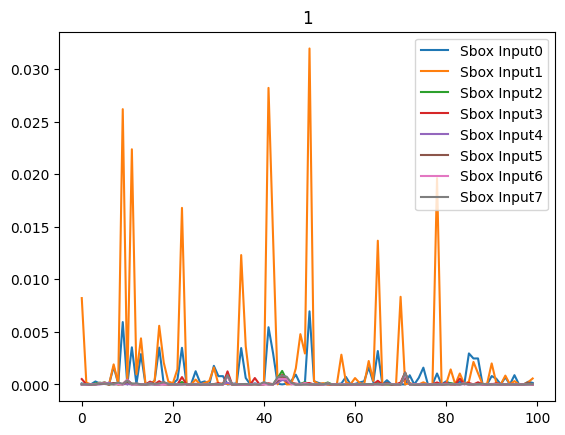

(200000, 16)
0 0.07361690778930977
1 0.10088100393312634
2 0.0034505880017713358
3 0.014982357354818673
4 0.0019851452093669958
5 0.0030265005944786344
6 0.003060797790927331
7 0.003578509750289981


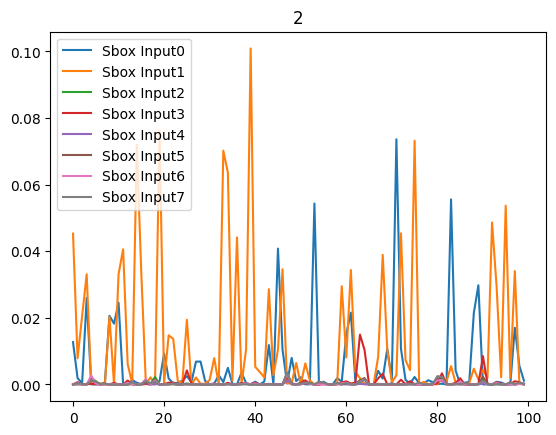

(200000, 16)
0 0.2007062737407251
1 0.3142203475457218
2 0.0127574244258499
3 0.024171338607049075
4 0.002981511646332141
5 0.016449943290570115
6 0.011681455534360874
7 0.010026763024731064


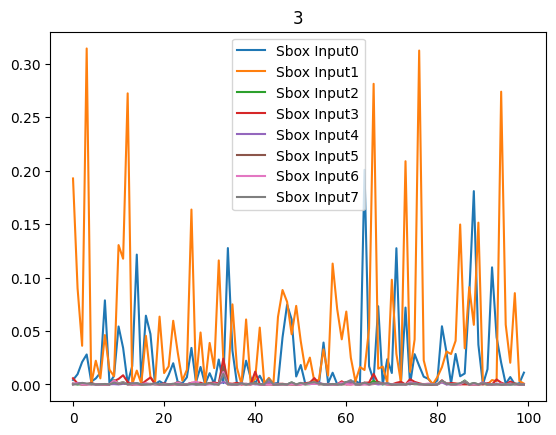

(200000, 16)
0 0.31878452332473023
1 0.70139944597358
2 0.012811586762426708
3 0.023756434335856474
4 0.003465843152004068
5 0.011408398959738037
6 0.011631878900255854
7 0.010678069144793937


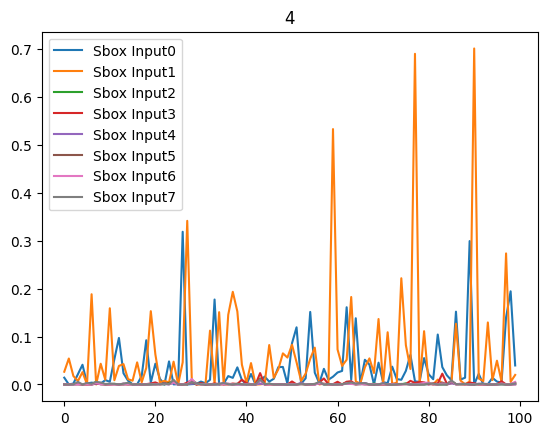

(200000, 16)
0 0.2499297313571672
1 0.988102701027729
2 0.011265272481685134
3 0.019305555617636253
4 0.006761569660800088
5 0.0096970198129205
6 0.009432651736522003
7 0.010087442078973585


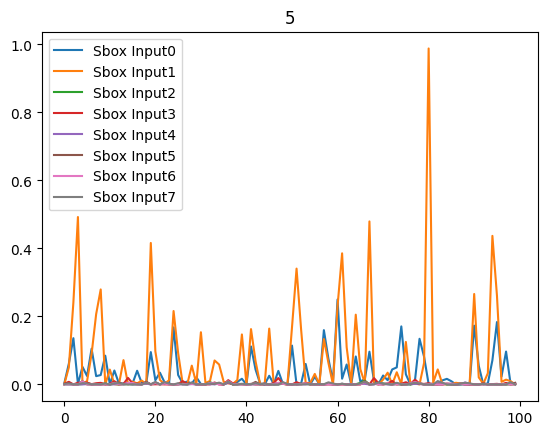

(200000, 16)
0 0.25645742853135145
1 0.4968096792919623
2 0.012395375459884918
3 0.02862694592606279
4 0.007025786117114051
5 0.01724177084632688
6 0.013212128301648383
7 0.018730164769285327


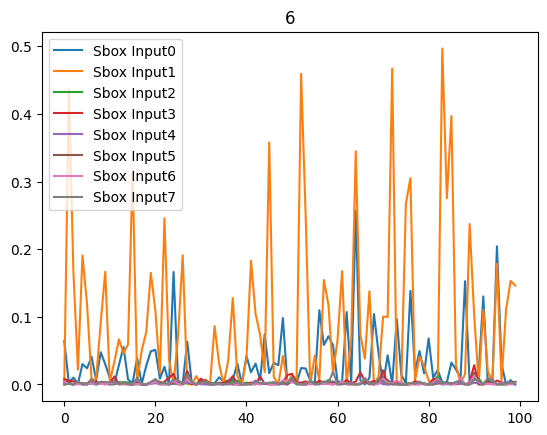

(200000, 16)
0 0.04383701377506313
1 0.04694946169398471
2 0.008201763791739633
3 0.009035666006219177
4 0.004552452447208041
5 0.008403999615394049
6 0.009426089053476644
7 0.008117211986753138


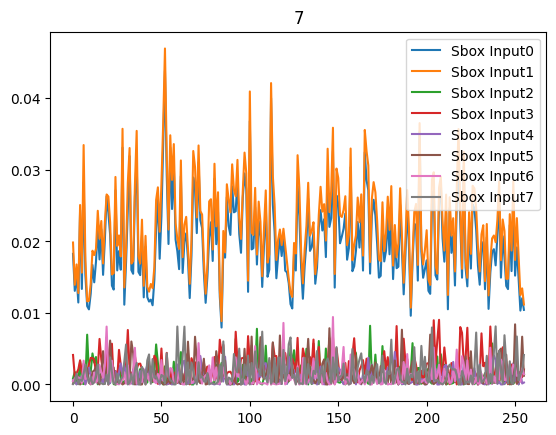

In [10]:
#print(tmp[0].shape)

for i in range(len(tmp)):
    print(dataset.profiling_plaintexts.shape)
    for j in range(8):
        snr_locals = snr_fast(tmp[i], ((dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))>>j)&0x1)
        print(j, max(snr_locals))
        plt.plot(snr_locals, label=f"Sbox Input{j}")
    #plt.plot(snr_fast(tmp[i], dataset.profiling_labels), label="Sbox")
    plt.legend()
    plt.title(i)
    plt.show()

In [13]:
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

layer_out = 4
def retrain_probes_per_bit():

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

retrain_probes_per_bit()


Epoch 1/5
 19/500 [>.............................] - ETA: 1s - loss: 1.7433 - accuracy: 0.5571  

2024-11-28 10:12:45.021925: I external/local_xla/xla/service/service.cc:168] XLA service 0x56030bacbca0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-28 10:12:45.021954: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2024-11-28 10:12:45.031573: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-28 10:12:45.050972: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1732785165.089630    1118 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 [==============================] - 1s 2ms/step - loss: 0.4626 - accuracy: 0.8067
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2775 - accuracy: 0.8672
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2644 - accuracy: 0.8730
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2602 - accuracy: 0.8750
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.2589 - accuracy: 0.8750
Epoch 1/5
500/500 [==============================] - 1s 2ms/step - loss: 0.5629 - accuracy: 0.7321
Epoch 2/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3957 - accuracy: 0.8114
Epoch 3/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3814 - accuracy: 0.8186
Epoch 4/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3779 - accuracy: 0.8199
Epoch 5/5
500/500 [==============================] - 1s 2ms/step - loss: 0.3771 - accuracy: 0.8203
Epoch 1/5
500/500 [=

In [ ]:
acc_per_probe = []
#from tf.keras.metrics import acc
layer_out=4
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in range(8):
    y_pred = probes_for_bit[i].predict(tmp_att[layer_out])
    y_true = (dataset.attack_labels.astype(np.uint8) >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")


for i in range(8):
    y_pred = probes_for_bit[i+8].predict(tmp_att[layer_out])
    y_true = (sbox_ins_att >>(i))&0x1
    acc = np.sum(np.equal(y_true, np.argmax(y_pred, axis=1)))/y_true.shape[0]
    print(f"Bit: {i}, acc: {acc}")



313/313 [==============================] - 0s 1ms/step
Bit: 0, acc: 0.8052
313/313 [==============================] - 0s 945us/step
Bit: 1, acc: 0.7274
313/313 [==============================] - 0s 880us/step
Bit: 2, acc: 0.5379
313/313 [==============================] - 0s 907us/step
Bit: 3, acc: 0.5469
313/313 [==============================] - 0s 900us/step
Bit: 4, acc: 0.5414
313/313 [==============================] - 0s 895us/step
Bit: 5, acc: 0.5325
313/313 [==============================] - 0s 999us/step
Bit: 6, acc: 0.5539
313/313 [==============================] - 0s 990us/step
Bit: 7, acc: 0.5411
313/313 [==============================] - 0s 945us/step
Bit: 0, acc: 0.8053
313/313 [==============================] - 0s 962us/step
Bit: 1, acc: 0.8788
313/313 [==============================] - 0s 943us/step
Bit: 2, acc: 0.5209
313/313 [==============================] - 0s 907us/step
Bit: 3, acc: 0.531
313/313 [==============================] - 0s 920us/step
Bit: 4, acc: 0.5316
31

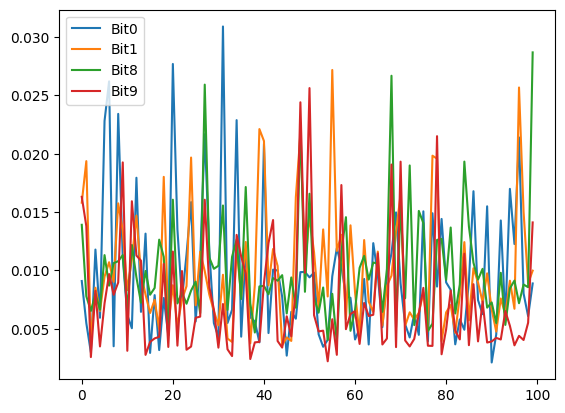

In [ ]:


new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
bit_on_sum = np.zeros(100)
bit_off_sum = np.zeros(100)
indices,  = np.where((dataset.share5_profiling[dataset.target_byte, :].astype(np.uint8)>>1)&0x1==1)
not_indices,  = np.where((dataset.share5_profiling[dataset.target_byte, :].astype(np.uint8)>>1)&0x1==0)
#print(not_indices)
in_neurons = tf.Variable(tmp[layer])

for i in [0, 1, 8, 9]:#, 1, 8, 9]:
    with tf.GradientTape() as tape:
        inter = new_model_for_probe(in_neurons, training=False)
        
        predicts =  probes_for_bit[i](inter, training=False)[:, 1]
        #oss = tf.keras.losses.CategoricalCrossentropy()(y, pred)

    grads = tape.gradient(predicts, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.average(dgrad_abs.numpy(), axis=0)

    #print(inf_score)
    
    plt.plot(inf_score, label=f"Bit{i}")
# plt.plot(bit_on_sum)
# plt.plot(bit_off_sum)
plt.legend()
plt.show()

In [12]:
layer = 1
layer_out=4
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
new_probe = train_linear_probe(tmp[layer_out], sbox_ins, epochs=40)
print(information(new_probe.predict(tmp_att[layer_out]), sbox_ins_att, 256))
from sklearn.metrics import accuracy_score
COMPS = 32

#orig_preds = model.predict(dataset.x_profiling)
pca = PCA(n_components=COMPS)
pca.fit(tmp[layer])
s1_prof = pca.transform(tmp[layer])
s1_att = pca.transform(tmp_att[layer])
print(layer)
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
patched_activs = s1_prof.copy()

from profiling_and_attack import information
#print(accuracy_score((sbox_ins_att>>0)&0x1, np.argmax(probes_for_bit[0].predict(new_model_for_probe.predict(tmp_att[1])), axis=1)))
#print(accuracy_score((sbox_ins_att>>0)&0x1, np.argmax(probes_for_bit[0].predict(new_model_for_probe.predict(pca.inverse_transform(s1_att))), axis=1)))
ablated_list_pis_in = []
probe_input_clean = new_model_for_probe.predict(pca.inverse_transform(s1_att))
clean_pi = information(new_probe.predict(probe_input_clean), sbox_ins_att, 256)
print(clean_pi)
for comp in range(s1_prof.shape[1]):
    patched_activs = s1_att.copy()
    patched_activs[:, comp] = 0
    probe_input = new_model_for_probe.predict(pca.inverse_transform(patched_activs))
    ablated_preds= new_probe.predict(probe_input)
    # for k in range(8):
    #     lab_bit = (sbox_ins_att>>k)&0x1
    #     clean_preds = new_model_for_probe.predict(pca.inverse_transform(patched_activs))
    #     orig_pi = information(clean_preds, lab_bit, 2)
    #     ablated_preds = probes_for_bit[k].predict(probe_input)

    ablated_list_pis_in.append(information(ablated_preds, sbox_ins_att, 256))

    print(comp, ablated_list_pis_in[-1])


NameError: name 'sbox_ins' is not defined

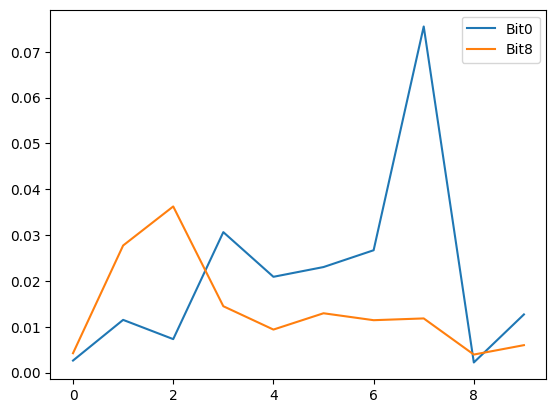

In [ ]:
#reload_model(20)
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
bit_on_sum = np.zeros(100)
bit_off_sum = np.zeros(100)
indices,  = np.where((dataset.share5_profiling[dataset.target_byte, :].astype(np.uint8)>>1)&0x1==1)
not_indices,  = np.where((dataset.share5_profiling[dataset.target_byte, :].astype(np.uint8)>>1)&0x1==0)
#print(not_indices)
comp_n = 10
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
in_neurons = tf.Variable(new_s1_att)

inf_scores = np.zeros((16, comp_n))
for i in [0, 8]:
    with tf.GradientTape() as tape:
        inter = new_pca.inverse_transform(in_neurons)
        inter = new_model_for_probe(inter, training=False)
        
        predicts =  probes_for_bit[i](inter, training=False)[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        #oss = tf.keras.losses.CategoricalCrossentropy()(y, pred)

    grads = tape.gradient(predicts, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.average(dgrad_abs.numpy(), axis=0)
    inf_scores[i] = inf_score
    #print(inf_score)
    
    plt.plot(inf_score, label=f"Bit{i}")
# plt.plot(bit_on_sum)
# plt.plot(bit_off_sum)
plt.legend()
plt.show()

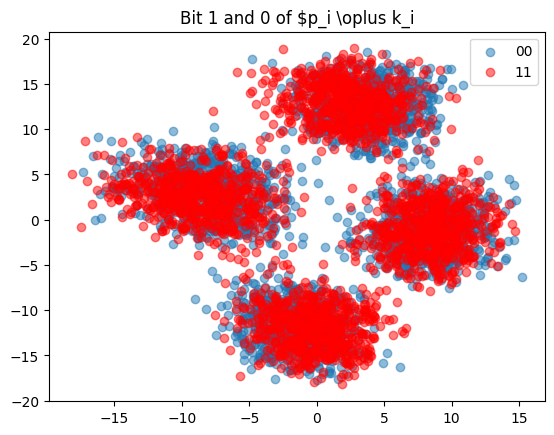

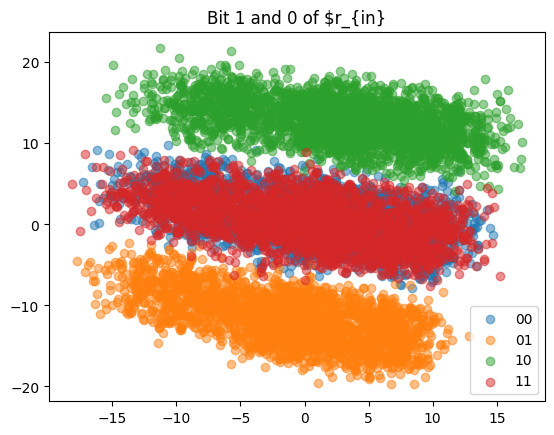

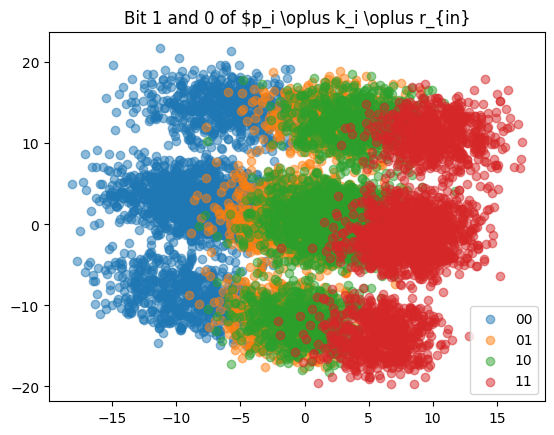

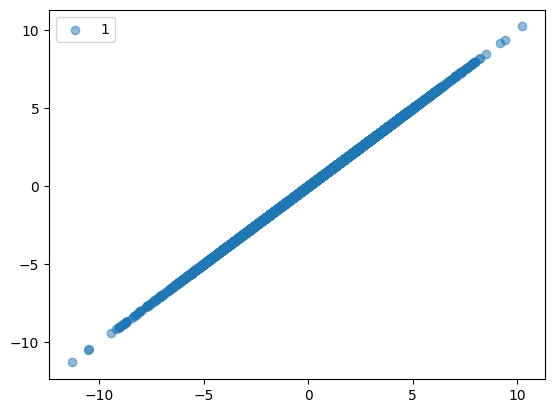

In [ ]:
on = np.where(sbox_ins_att&0x3==0)
off = np.where(sbox_ins_att&0x3==1)
on2 = np.where(sbox_ins_att&0x3==2)
off3 = np.where(sbox_ins_att&0x3 ==3)

plt.scatter(new_s1_att[on, 2], new_s1_att[on, 1], label="00", alpha=0.5)
#plt.scatter(new_s1_att[off, 2], new_s1_att[off, 1],c='#ff7f0e', label="01", alpha=0.5)
#plt.scatter(new_s1_att[on2, 2], new_s1_att[on2, 1],c='g',  label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, 2], new_s1_att[off3, 1], c='r', label="11", alpha=0.5)
plt.legend()
plt.title("Bit 1 and 0 of $p_i \oplus k_i")
plt.savefig("ptxk0011.png")
plt.show()
plt.close()


# on = np.where(sbox_ins&0x1==0)
# off = np.where(sbox_ins&0x1==1)
# on2 = np.where(sbox_ins&0x3==2)
# off3 = np.where(sbox_ins&0x3 ==3)

# plt.scatter(new_s1_prof[on, 2], new_s1_prof[on, 1], label="00", alpha=0.5)
# plt.scatter(new_s1_prof[off, 2], new_s1_prof[off, 1],c='#ff7f0e', label="01", alpha=0.5)
# plt.scatter(new_s1_prof[on2, 2], new_s1_prof[on2, 1],c='g',  label="10", alpha=0.5)
# plt.scatter(new_s1_prof[off3, 2], new_s1_prof[off3, 1], c='r', label="11", alpha=0.5)
# plt.legend()
# plt.show()
# plt.close()



on = np.where(dataset.share6_attack[ target_byte].astype(np.uint8)&0x3==0)
off = np.where(dataset.share6_attack[target_byte].astype(np.uint8)&0x3 ==1)
on2 = np.where(dataset.share6_attack[target_byte].astype(np.uint8)&0x3==2)
off3 = np.where(dataset.share6_attack[target_byte].astype(np.uint8)&0x3 ==3)


plt.scatter(new_s1_att[on, 2], new_s1_att[on, 1], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, 2], new_s1_att[off, 1], label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, 2], new_s1_att[on2, 1], label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, 2], new_s1_att[off3, 1], label="11", alpha=0.5)
plt.legend()
plt.title("Bit 1 and 0 of $r_{in}")
plt.savefig("rin.png")
plt.show()

on = np.where(dataset.share5_attack[ target_byte].astype(np.uint8)&0x3==0)
off = np.where(dataset.share5_attack[target_byte].astype(np.uint8)&0x3 ==1)
on2 = np.where(dataset.share5_attack[target_byte].astype(np.uint8)&0x3==2)
off3 = np.where(dataset.share5_attack[target_byte].astype(np.uint8)&0x3 ==3)


plt.scatter(new_s1_att[on, 2], new_s1_att[on, 1], label="00", alpha=0.5)
plt.scatter(new_s1_att[off, 2], new_s1_att[off, 1], label="01", alpha=0.5)
plt.scatter(new_s1_att[on2, 2], new_s1_att[on2, 1], label="10", alpha=0.5)
plt.scatter(new_s1_att[off3, 2], new_s1_att[off3, 1], label="11", alpha=0.5)
plt.legend()
plt.title("Bit 1 and 0 of $p_i \oplus k_i \oplus r_{in}")
plt.savefig("ptxkxr.png")
plt.show()

on = np.where(dataset.attack_labels&0x1==0)
off = np.where(dataset.attack_labels&0x1 ==1)
# on2 = np.where(dataset.attack_labels&0x3==2)
# off3 = np.where(dataset.attack_labels&0x3 ==3)

#plt.scatter(new_s1_att[on, 7], new_s1_att[on, 7], label="0", alpha=0.5)
plt.scatter(new_s1_att[off, 7], new_s1_att[off, 7], label="1", alpha=0.5)
# plt.scatter(new_s1_att[on2, 6], new_s1_att[on2, 7], label="10", alpha=0.5)
# plt.scatter(new_s1_att[off3, 6], new_s1_att[off3, 7], label="11", alpha=0.5)
plt.legend()
plt.show()
plt.close()

313/313 [==============================] - 0s 1ms/step


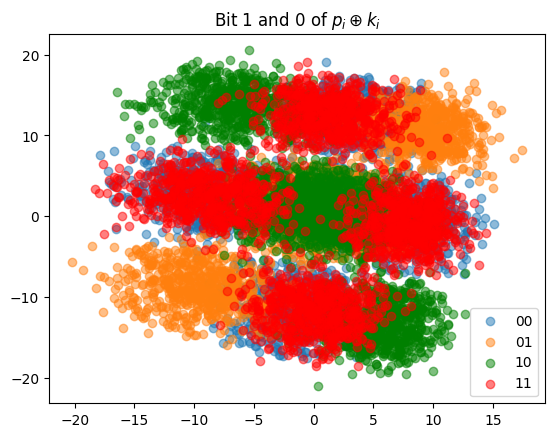

In [ ]:
reload_model(42)
new_pca = PCA(32)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


In [ ]:
fix_in_01 = new_s1_att.copy()
fix_in_01[:, 2] = -10
fix_in_01[:, 1] = -12.5
outs = []
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
patched_activs = new_model_for_probe.predict(new_pca.inverse_transform(fix_in_01))
for i in range(8):
    outs.append(probes_for_bit[i].predict(patched_activs))





313/313 [==============================] - 0s 847us/step
[array([[1.1070984e-01, 8.8929015e-01],
       [6.7946166e-01, 3.2053828e-01],
       [9.4641370e-01, 5.3586315e-02],
       ...,
       [6.6739754e-05, 9.9993324e-01],
       [7.6726028e-03, 9.9232739e-01],
       [8.0344570e-01, 1.9655429e-01]], dtype=float32), array([[0.46414733, 0.5358527 ],
       [0.32505202, 0.6749479 ],
       [0.4428007 , 0.55719924],
       ...,
       [0.21981274, 0.7801873 ],
       [0.77570564, 0.22429436],
       [0.3018233 , 0.6981767 ]], dtype=float32), array([[0.49370256, 0.50629747],
       [0.40278652, 0.59721345],
       [0.55566037, 0.44433963],
       ...,
       [0.53818697, 0.46181303],
       [0.402933  , 0.597067  ],
       [0.48796487, 0.51203513]], dtype=float32), array([[0.54066277, 0.45933726],
       [0.54250836, 0.45749167],
       [0.50005525, 0.49994478],
       ...,
       [0.42434955, 0.5756505 ],
       [0.5738912 , 0.42610875],
       [0.4915939 , 0.5084061 ]], dtype=float32)

In [63]:
indices_00, = np.where(dataset.attack_labels % 4 == 0)
print(np.sum((np.argmax(outs[4][indices_00],axis=1))))

1679


In [18]:
for epoch in range(100,101):
    reload_model(epoch)
    comp_n = 16
    new_pca = PCA(n_components=comp_n)
    new_s1_prof = new_pca.fit_transform(tmp[layer])
    new_s1_att = new_pca.transform(tmp_att[layer])
    on = np.where(sbox_ins_att&0x3==0)
    off = np.where(sbox_ins_att&0x3==1)
    on2 = np.where(sbox_ins_att&0x3==2)
    off3 = np.where(sbox_ins_att&0x3 ==3)

    plt.scatter(new_s1_att[on, 2], new_s1_att[on, 1], label="00", alpha=0.5)
    plt.scatter(new_s1_att[off, 2], new_s1_att[off, 1],c='#ff7f0e', label="01", alpha=0.5)
    plt.scatter(new_s1_att[on2, 2], new_s1_att[on2, 1],c='g',  label="10", alpha=0.5)
    plt.scatter(new_s1_att[off3, 2], new_s1_att[off3, 1], c='r', label="11", alpha=0.5)
    plt.legend()
    plt.title(f"Bit 1 and 0 of $p_i \oplus k_i$ Epoch {epoch}")
    plt.savefig(f"epoch_pcas/ptxk_epoch_{epoch}.png")
    #plt.show()
    plt.close()

313/313 [==============================] - 0s 1ms/step


In [ ]:
pi_l = []
sos_l = []
for epoch in range(1, 101):
    pi, sos = reload_model_att(epoch)
    pi_l.append(pi)
    sos_l.append(sos)
    print(epoch, pi, sos)

14
313/313 [==============================] - 0s 1ms/step


1 -0.02085162131673613 [13.352777, 0.1421446, 2.861825, 0.107162654, 2.79829, 0.06255792, 2.7825763, 0.05748384, 2.8399508, 0.054769464, 2.9398339, 0.068157256, 12.000465, 0.14150259]
14
313/313 [==============================] - 0s 1ms/step


2 -0.020504415201010987 [13.752828, 0.22460026, 2.856913, 0.14172722, 2.715346, 0.07671947, 2.6801257, 0.05081612, 2.7734463, 0.050046943, 2.9494703, 0.0877696, 12.020656, 0.22318856]
14
313/313 [==============================] - 0s 1ms/step


3 -0.020893160318208037 [14.347878, 0.2986965, 2.8962166, 0.18886444, 2.6757526, 0.100098625, 2.5978894, 0.06944848, 2.7135496, 0.050952666, 2.957882, 0.094359614, 12.047291, 0.2785766]
14
313/313 [==============================] - 0s 1ms/step


4 -0.021827376626792284 [15.08127, 0.34082815, 2.9992623, 0.20935492, 2.7055418, 0.11207981, 2.576751, 0.06880812, 2.6972034, 0.0510231, 2.981191, 0.099713676, 12.081201, 0.3172116]
14
313/313 [==============================] - 0s 997us/step


...

95 2.480216178060703 [47.33649, 3.7408602, 14.039768, 2.4153538, 13.063706, 2.1768024, 13.128108, 2.0295038, 13.316432, 1.66552, 13.099837, 1.1467522, 24.497177, 1.5663358]
14
313/313 [==============================] - 0s 977us/step


96 2.3944264754545097 [47.513084, 3.7625582, 14.090175, 2.4301562, 13.114329, 2.1950285, 13.180398, 2.0482194, 13.367896, 1.6796182, 13.155873, 1.1561191, 24.587887, 1.5723343]
14
313/313 [==============================] - 0s 1ms/step


97 2.413814417196442 [47.688705, 3.7837398, 14.134559, 2.4451785, 13.15982, 2.214293, 13.227264, 2.0711694, 13.418375, 1.694601, 13.2078085, 1.1642721, 24.675642, 1.5835174]
14
313/313 [==============================] - 0s 993us/step


98 2.4136118560087003 [47.86966, 3.80148, 14.182492, 2.4619422, 13.211654, 2.2349942, 13.277238, 2.091667, 13.468556, 1.7069229, 13.259119, 1.1736429, 24.760365, 1.5951025]
14
313/313 [==============================] - 0s 1ms/step


99 2.38193624260538 [48.038364, 3.82036, 14.229588, 2.476741, 13.259191, 2.2519343, 13.33099, 2.113719, 13.525456, 1.72522, 13.316852, 1.1827976, 24.857864, 1.6036171]
14
313/313 [==============================] - 0s 1ms/step
100 2.3646406790983057 [48.213673, 3.8397462, 14.273137, 2.488779, 13.306948, 2.2721553, 13.377758, 2.1363747, 13.5710335, 1.7429595, 13.366893, 1.1931489, 24.943895, 1.6135781]


In [49]:
np.sum(np.array(sos_l), axis=1)

array([ 40.209496,  40.603657,  41.317455,  42.321438,  44.030746,
        46.10462 ,  50.210857,  58.882442,  61.451538,  63.74294 ,
        65.62329 ,  67.60133 ,  69.91184 ,  72.048225,  74.33558 ,
        76.51871 ,  78.66981 ,  80.64412 ,  82.362274,  83.954025,
        85.395424,  86.79444 ,  88.146675,  89.44147 ,  90.83618 ,
        92.08746 ,  93.37131 ,  94.62833 ,  95.88771 ,  97.078835,
        98.292   ,  99.53731 , 100.72851 , 101.861916, 103.00865 ,
       104.18201 , 105.29768 , 106.43538 , 107.5373  , 108.604866,
       109.65182 , 110.70887 , 111.7507  , 112.768555, 113.75751 ,
       114.75637 , 115.73512 , 116.69508 , 117.61586 , 118.54942 ,
       119.48549 , 120.395096, 121.30471 , 122.18848 , 123.089386,
       123.98683 , 124.856804, 125.69842 , 126.56555 , 127.42139 ,
       128.275   , 129.10161 , 129.93921 , 130.76999 , 131.58162 ,
       132.39949 , 133.19649 , 133.97897 , 134.7863  , 135.56366 ,
       136.32071 , 137.10667 , 137.8857  , 138.62302 , 139.404

In [1]:
list_00 = []
list_01 = []
list_10 = []
list_11 = []

matrix = np.zeros((16, 8))
for i in range(256):
    for bit in range(8):
        matrix[i%4 + (aes_sbox[i]&0x3)*4, bit] += (aes_sbox[i]>>bit) &0x1

    if i % 4 == 0:
        list_00.append(aes_sbox[i]%4)

    if i % 4 == 1:
        list_01.append(aes_sbox[i]%4)
    if i % 4 == 2:
        list_10.append(aes_sbox[i]%4)

    if i % 4 == 3:
        list_11.append(aes_sbox[i]%4)
            
print(matrix)

    

NameError: name 'np' is not defined

In [ ]:
def transform_with_bitwise_difference(prob_dist, diff, classes=256):
    """
    Transforms a probability distribution of 256 classes using bitwise difference.
    
    :param prob_dist: A list or numpy array of 256 probability values (should sum to 1 or close to it).
    :return: A transformed probability distribution.
    """
    transformed_dist = np.zeros_like(prob_dist)
    
    # Apply a bitwise operation on each index (you can use XOR, AND, or OR as needed)
    for i in range(classes):
        # Example: XOR the probability index (i) with a fixed bitmask
        transformed_index = i ^ (( diff)%classes)  # XOR with an arbitrary bitmask
        transformed_dist[:, transformed_index % classes] = prob_dist[:, i]
    #print(transformed_dist.shape)
    return transformed_dist

[1.6204031272184145, 0.49901086037271397, 0.4175932669889255, 1.4675999999295974, 1.4588262107145122, 1.1809387381803367, 1.3207271186124612, 1.4019791594754916, 1.6248013823758831, 1.5638168433439084, 1.3622679213773552, 1.5934313872587038, 1.5305559676419973, 1.5937868842374552, 1.5751270507108481, 1.5583120368253538, 1.6146782523404903, 1.583449741293127, 1.6033833899747647, 1.6130219588529304, 1.608175624014076, 1.5991666762601648, 1.6200564505826696, 1.614272516561677, 1.6145880378019144, 1.61770329353922, 1.5914646437894628, 1.6109832289945376, 1.6154117003690498, 1.6239867057096344, 1.6164289992582122, 1.6279017089139756]


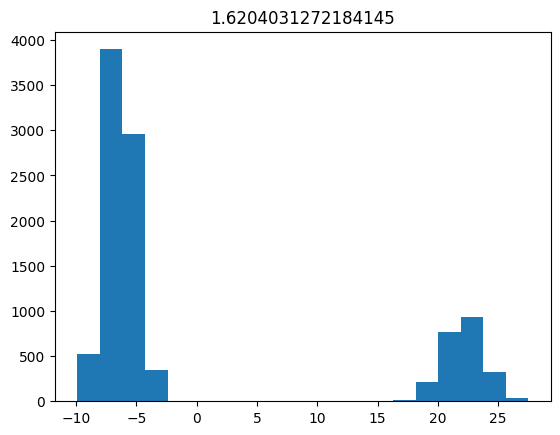

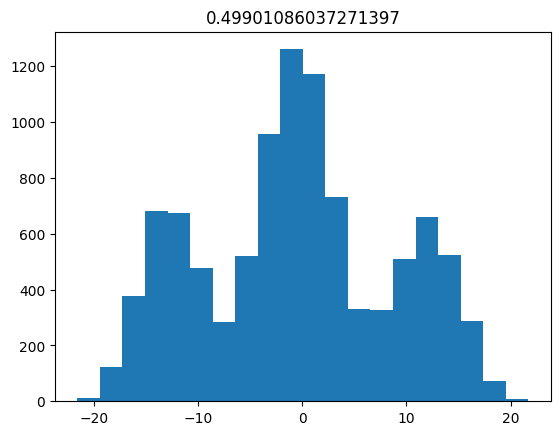

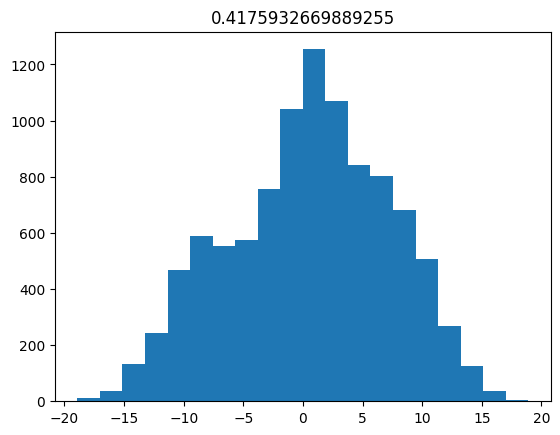

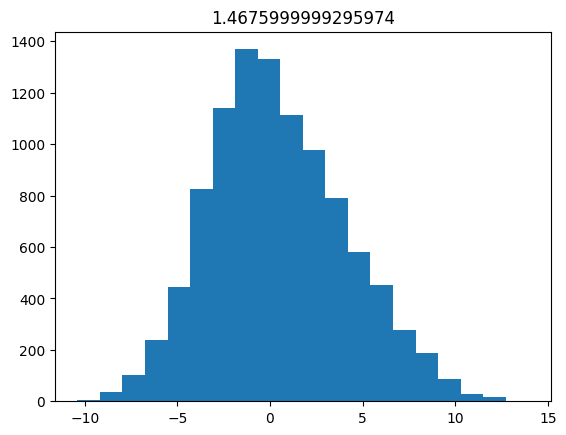

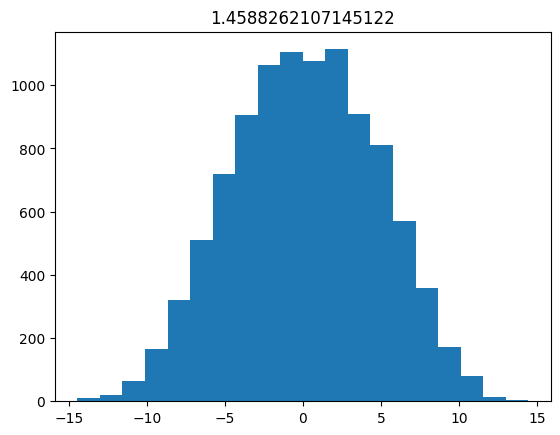

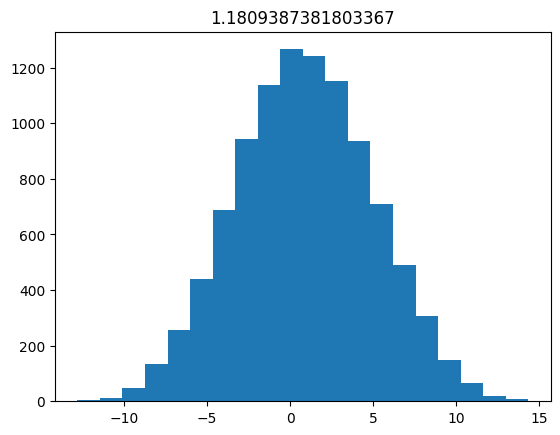

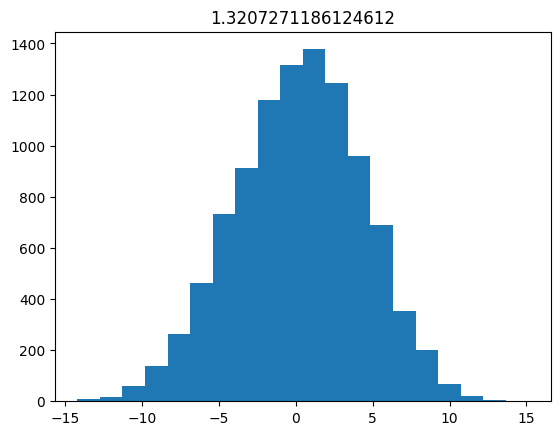

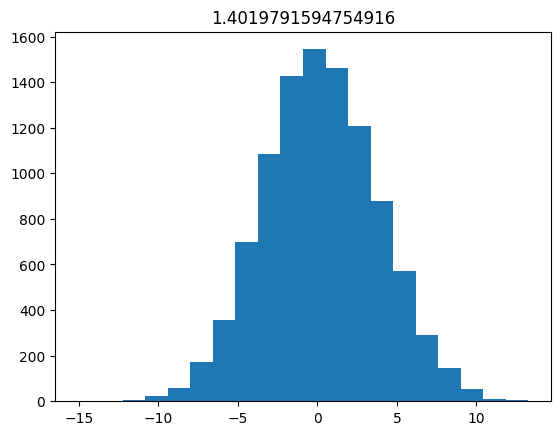

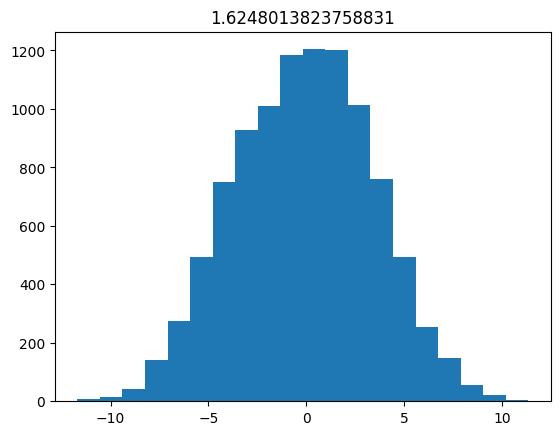

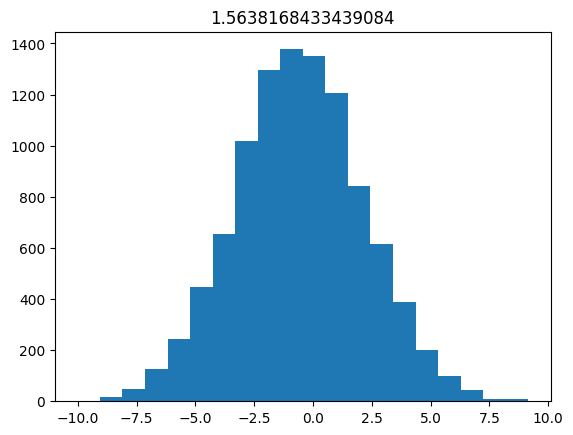

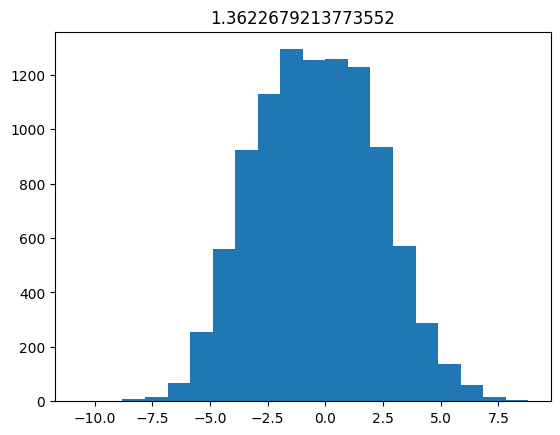

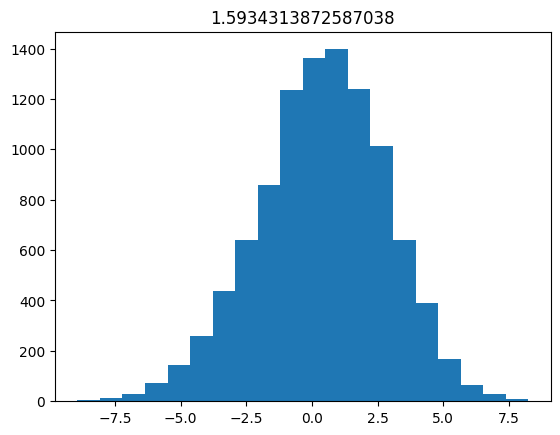

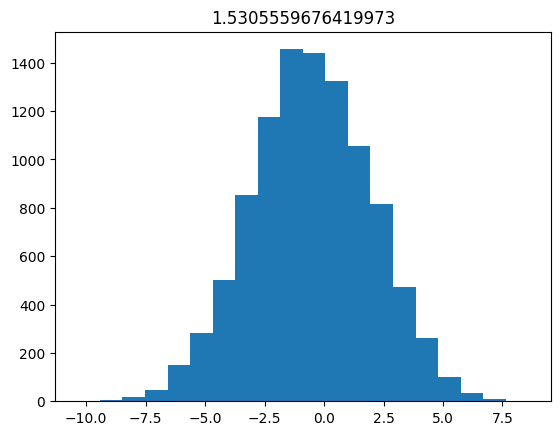

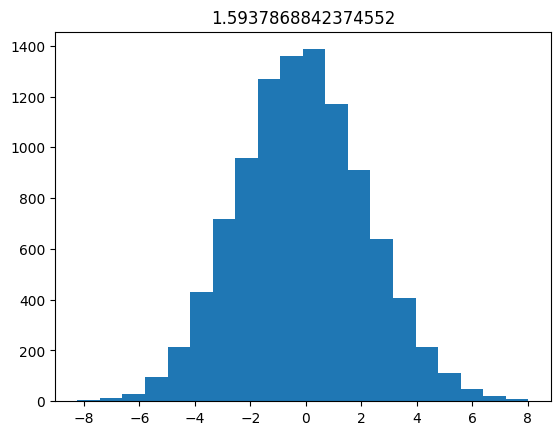

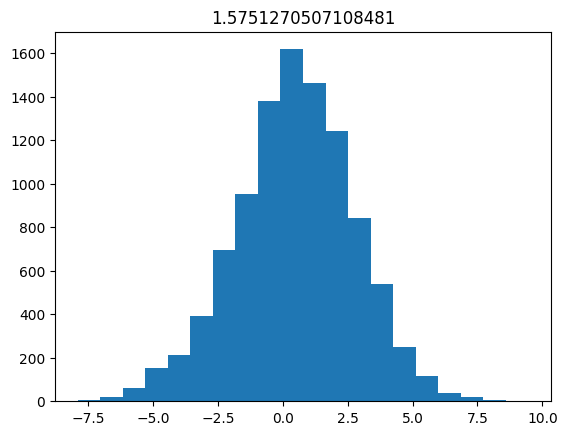

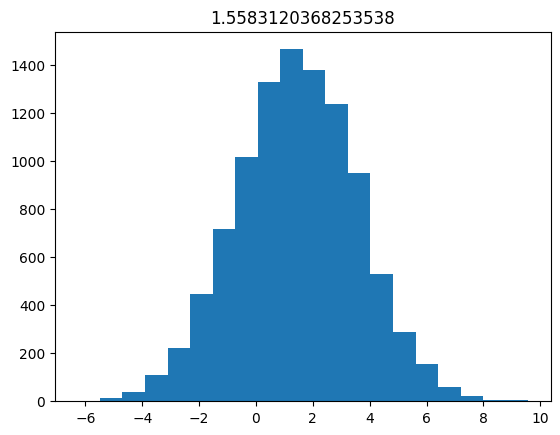

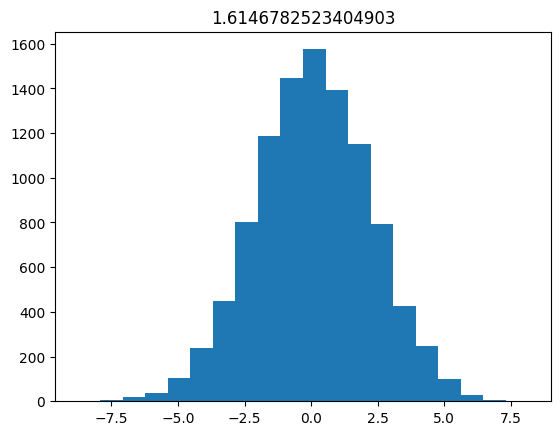

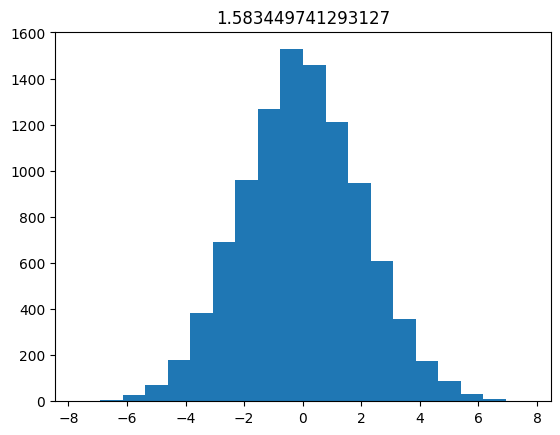

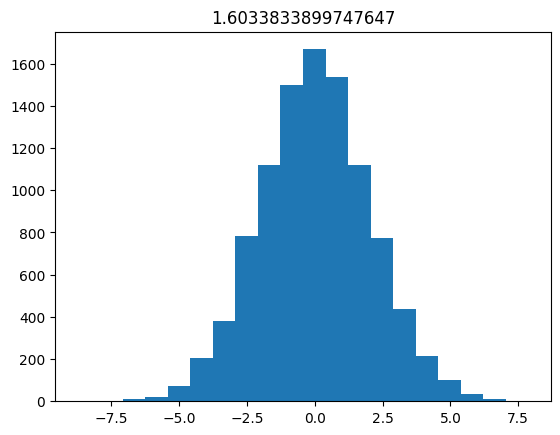

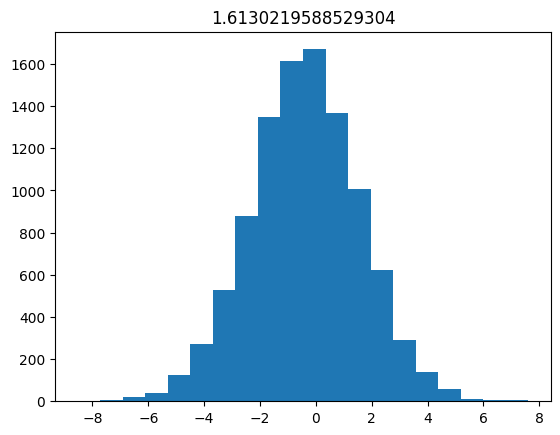

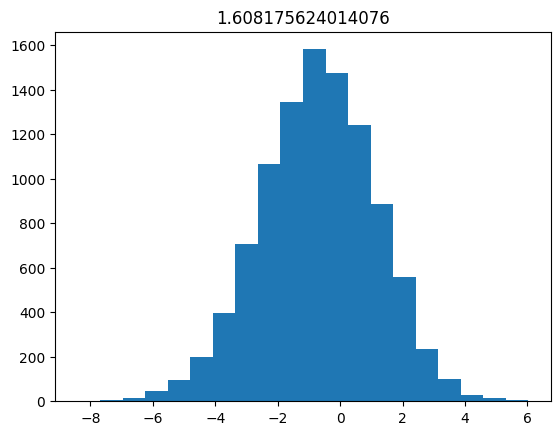

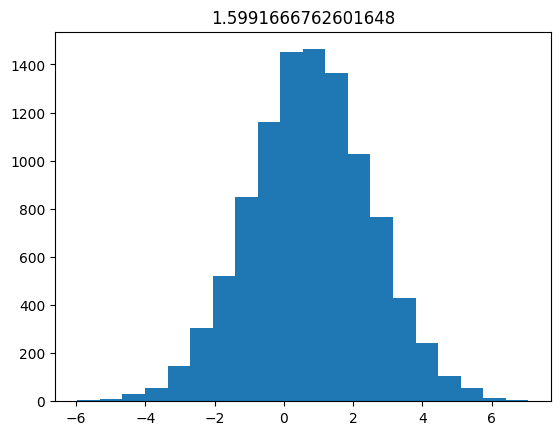

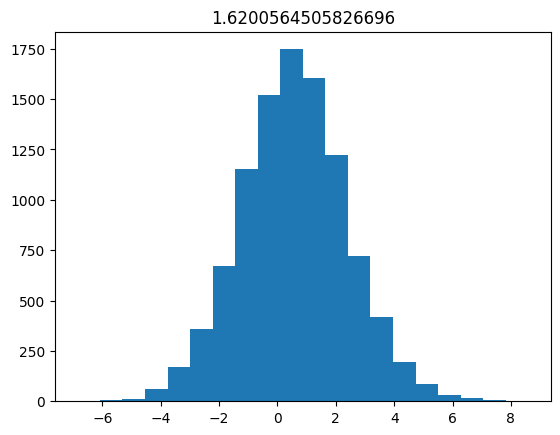

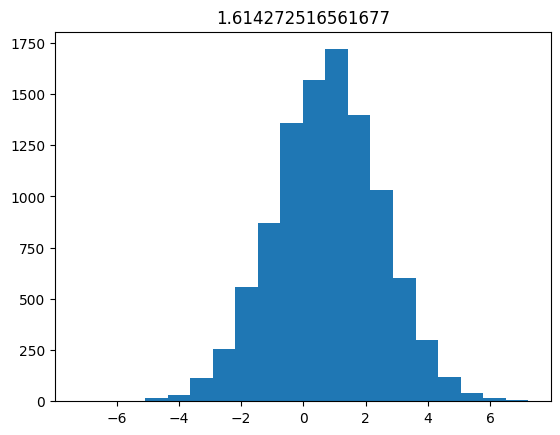

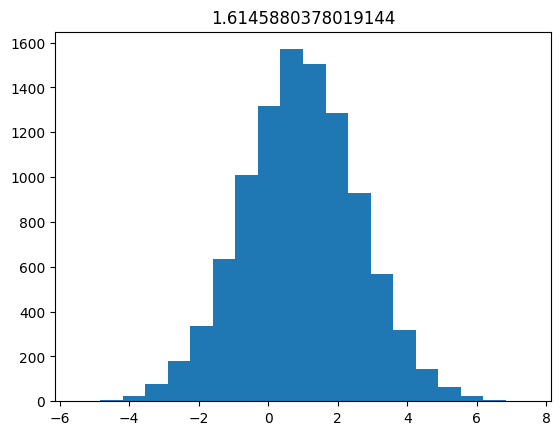

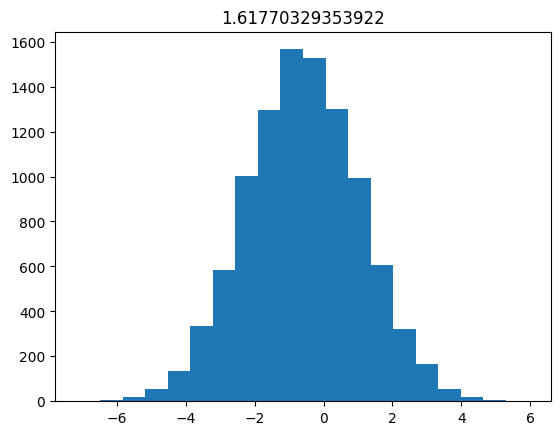

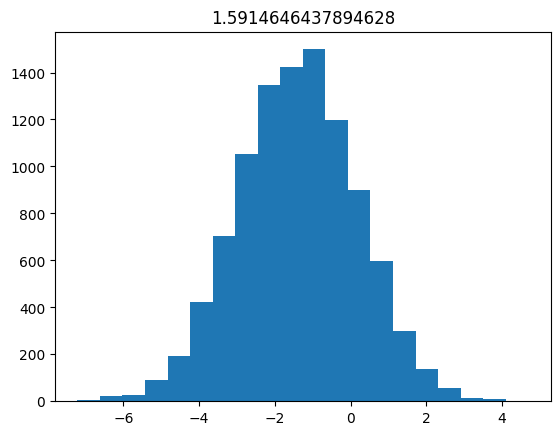

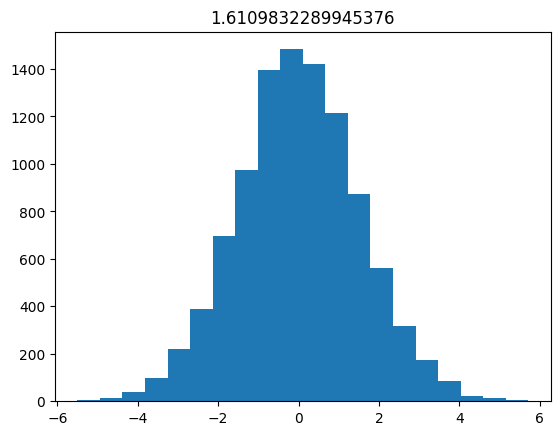

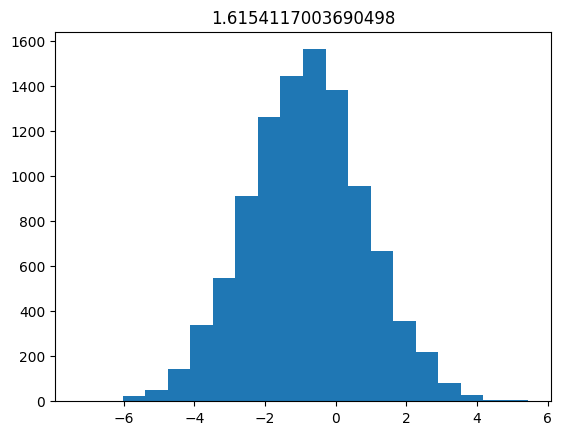

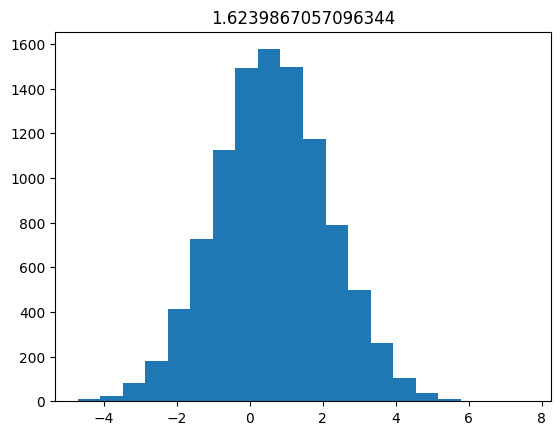

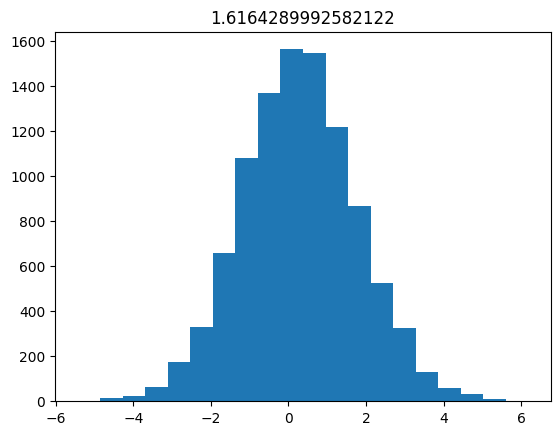

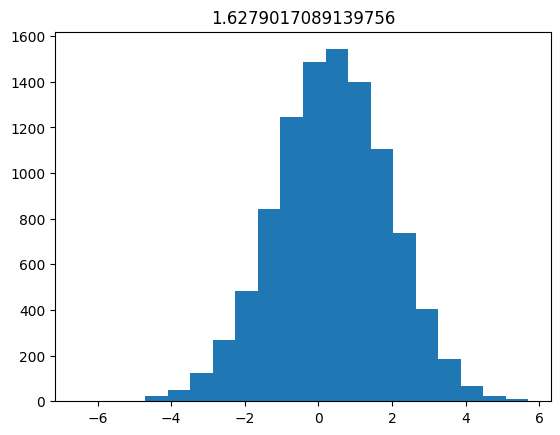

In [ ]:
print(ablated_list_pis_in)

for i in range(COMPS):
    plt.hist(s1_att[:, i], bins=20)
    plt.title(ablated_list_pis_in[i])
    plt.show()


In [ ]:

fix1 = s1_att.copy()
fix2 = s1_att.copy()
s1_prof_ablate = s1_prof.copy()
#s1_prof_ablate[:, 5:] = 0
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
#new_probe = train_linear_probe(tmp[layer_out], sbox_ins%4, epochs=10)
# import random
# f1_i = random.randint(0, s1_att.shape[0])
# f2_i = random.randint(0, s1_att.shape[0])
fix1[:,2] = -5#s1_prof[f1_i, 2]
fix2[:, 2] = 10#s1_prof[f2_i, 2]
#mask_diff = dataset.share5_profiling[target_byte, f1_i].astype(np.uint8)^ dataset.share5_profiling[target_byte,f2_i].astype(np.uint8) 
#print(dataset.attack_masks.shape)
preds_f1 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix1)))
preds_f2 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix2)))
#print(mask_diff, tf.keras.metrics.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, mask_diff, 256)))

scores = []
scores_dist = []
for i in range(256):
 scores.append(tf.keras.metrics.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, i, 256)).numpy())
 scores_dist.append(np.average(np.sum(np.abs(preds_f1 - transform_with_bitwise_difference(preds_f2, i, 256)), axis=1)))
 #print(i, tf.keras.losses.KLDivergence()(preds_f2,transform_with_bitwise_difference(preds_f1, i)), tf.keras.losses.KLDivergence()(preds_f1,transform_with_bitwise_difference(preds_f2, i)))
 #print(i, scores[-1], scores_dist[-1])

print( [format(i,'08b') for i in np.argsort(scores)])
print( [format(i,'08b') for i in np.argsort(scores_dist)])



313/313 [==============================] - 0s 751us/step
['11001001', '10010101', '10001001', '01101101', '11100001', '01100001', '00000101', '01100101', '01001001', '01110101', '01111101', '10100001', '01110001', '10000101', '11010001', '00110001', '00110101', '01010101', '01011101', '00111001', '00111101', '10100101', '11010101', '10001101', '00101001', '11000001', '10101001', '00101101', '00010001', '10000001', '10111101', '11001101', '11100101', '11011001', '11101001', '10010001', '00011101', '10111001', '00100001', '10011001', '11101101', '10110001', '00001101', '01001101', '00010101', '01111001', '11000101', '01010001', '10101101', '01000001', '11011101', '00000001', '11111001', '10110101', '00100101', '00001001', '00011001', '11111101', '10011101', '01000101', '01011001', '11110101', '01101001', '11110001', '00000000', '01101011', '01000111', '10111111', '10110011', '01101111', '01001011', '00000111', '00110111', '11010111', '10000111', '10110111', '00100111', '01011011', '10101

In [ ]:
fix1 = s1_att.copy()
fix2 = s1_att.copy()
s1_prof_ablate = s1_prof.copy()
#s1_prof_ablate[:, 5:] = 0
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
#new_probe = train_linear_probe(tmp[layer_out], sbox_ins%4, epochs=10)
# import random
# f1_i = random.randint(0, s1_att.shape[0])
# f2_i = random.randint(0, s1_att.shape[0])
#fix1[:,2] = 0#s1_prof[f1_i, 2]
# fix2[:, 2] = 0#s1_prof[f2_i, 2]

ablate_higher = s1_att.copy()
ablate_higher[:, 3:9] = 0
ablate_higher[:, 10:] = 0

preds_f1 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(fix1)))
preds_f2 = new_probe.predict(new_model_for_probe.predict(pca.inverse_transform(ablate_higher)))

tf.keras.metrics.KLDivergence()(preds_f1, preds_f2)


313/313 [==============================] - 0s 778us/step


<tf.Tensor: shape=(), dtype=float32, numpy=0.9554555>